# import

In [1]:
import os
import gzip
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# configs

In [2]:
DATA_ROOT = "./data/Town04_Rep0_Town04_Scenario4_102_route0_11_08_03_33_41"

# check measurement

In [44]:
def get_gz_json(file_path):
    with gzip.open(file_path, "rt", encoding="utf-8") as f:
        data = json.load(f)
    return data


m_path = os.path.join(DATA_ROOT, "measurements/0000.json.gz")
data = get_gz_json(m_path)

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['pos_global', 'theta', 'speed', 'target_speed', 'speed_limit', 'target_point', 'target_point_next', 'command', 'next_command', 'aim_wp', 'route', 'route_original', 'changed_route', 'speed_reduced_by_obj_type', 'speed_reduced_by_obj_id', 'speed_reduced_by_obj_distance', 'steer', 'throttle', 'brake', 'control_brake', 'junction', 'vehicle_hazard', 'vehicle_affecting_id', 'light_hazard', 'walker_hazard', 'walker_affecting_id', 'stop_sign_hazard', 'stop_sign_close', 'walker_close', 'walker_close_id', 'angle', 'augmentation_translation', 'augmentation_rotation', 'ego_matrix'])


In [45]:
m_df = pd.DataFrame([data])
m_df.head()

,pos_global,theta,speed,target_speed,speed_limit,target_point,target_point_next,command,next_command,aim_wp,...,walker_hazard,walker_affecting_id,stop_sign_hazard,stop_sign_close,walker_close,walker_close_id,angle,augmentation_translation,augmentation_rotation,ego_matrix
0,"[210.31028747558594, -135.08680725097656]",-2.190257,0.234644,1.428359,13.888889,"[26.932974209958672, 8.900428674038592]","[41.99795014311358, 6.522442694547377]",4,4,"[10.259591268383854, 1.1818218665540612]",...,False,None,True,True,False,None,0.073012,-0.72961,3.438891,"[[-0.5805959701538086, 0.8141918182373047, -2...."


In [46]:
measurement_dir = Path(DATA_ROOT + "/measurements")

rows = []

for file in sorted(measurement_dir.glob("*.json.gz")):
    with gzip.open(file, "rt", encoding="utf-8") as f:
        data = json.load(f)

    data["frame"] = file.stem   # frame id 추가
    rows.append(data)

df = pd.DataFrame(rows)

print(df.head())
print(df.columns)

                                  pos_global     theta     speed  \
0  [210.31028747558594, -135.08680725097656] -2.190257  0.234644   
1  [210.31028747558594, -135.08673095703125] -2.190257  0.091376   
2   [210.3102264404297, -135.08670043945312] -2.190255  0.025350   
3   [210.20651245117188, -135.2887725830078] -2.168172  1.476998   
4  [209.95135498046875, -135.77871704101562] -2.129486  2.936521   

   target_speed  speed_limit                             target_point  \
0      1.428359    13.888889  [26.932974209958672, 8.900428674038592]   
1      1.035210    13.888889   [26.933036327867924, 8.90047296999147]   
2      0.969985    13.888889  [26.933038470566913, 8.900501854688553]   
3      2.338735    13.888889   [26.89759909322755, 8.275689090702318]   
4      3.666817    13.888889   [26.64684126101748, 7.185867772201446]   

                        target_point_next  command  next_command  \
0  [41.99795014311358, 6.522442694547377]        4             4   
1  [41.998012261

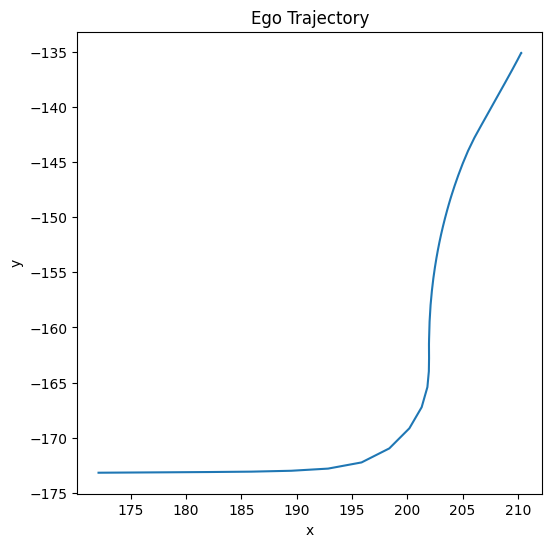

In [47]:
xs = df["pos_global"].apply(lambda x: x[0])
ys = df["pos_global"].apply(lambda x: x[1])

plt.figure(figsize=(6, 6))
plt.plot(xs, ys)
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ego Trajectory")
plt.show()

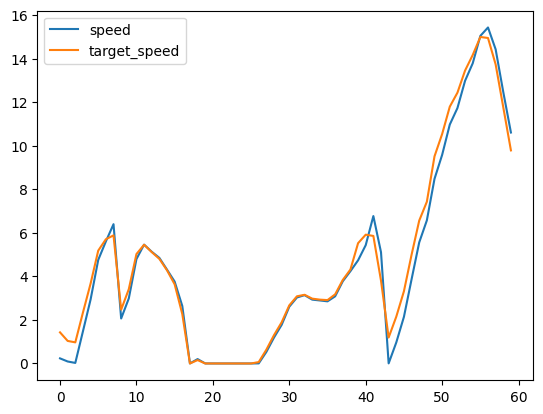

In [48]:
plt.plot(df["speed"], label="speed")
plt.plot(df["target_speed"], label="target_speed")
plt.legend()

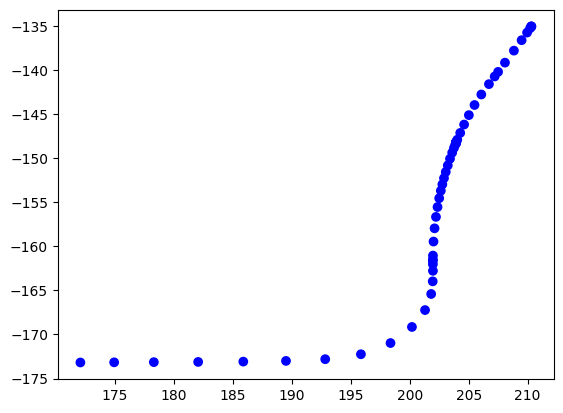

In [49]:
colors = df["vehicle_hazard"].map({True:"red", False:"blue"})

plt.scatter(xs, ys, c=colors)

# BEV Semantics

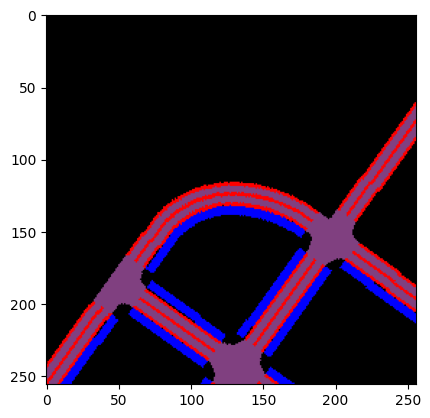

In [50]:
from PIL import Image

def visualize_semantic_mask(mask, color_map=None):
    """
    mask: (H, W) uint8/int array
    returns: RGB image (H, W, 3)
    """

    if color_map is None:
        color_map = {
            0: (0, 0, 0),         # black
            1: (128, 64, 128),   # road
            2: (0, 0, 255),      # vehicle
            3: (255, 0, 0),      # pedestrian
            4: (0, 255, 0),      # vegetation
            5: (255, 255, 0),    # lane
        }

    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        rgb[mask == class_id] = color

    return rgb

test_img_path = os.path.join(DATA_ROOT, 'bev_semantics', '0000.png')
mask = np.array(Image.open(test_img_path))
rgb = visualize_semantic_mask(mask)
plt.imshow(rgb)

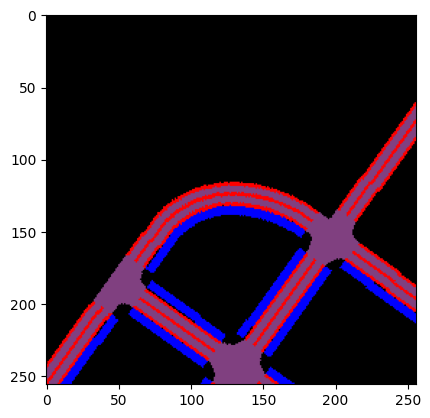

In [51]:
test_img_path = os.path.join(DATA_ROOT, 'bev_semantics_augmented', '0000.png')
mask = np.array(Image.open(test_img_path))
rgb = visualize_semantic_mask(mask)
plt.imshow(rgb)

# lidar

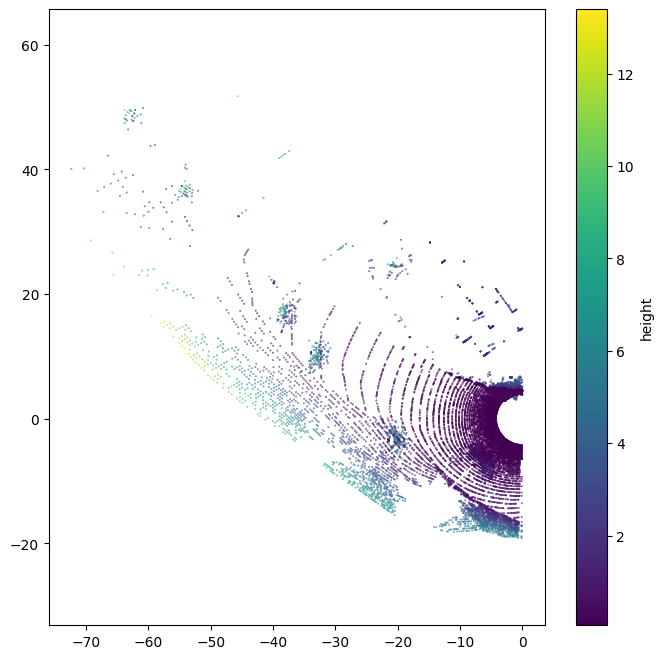

In [52]:
import laspy

test_lidar_path = os.path.join(DATA_ROOT, "lidar", "0000.laz")
las = laspy.read(test_lidar_path)

x = las.x
y = las.y
z = las.z

plt.figure(figsize=(8,8))
plt.scatter(x, y, s=0.1, c=z)
plt.axis("equal")
plt.colorbar(label="height")
plt.show()

In [53]:
import open3d as o3d
import numpy as np

points = np.vstack([x, y, z]).T

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

o3d.visualization.draw_geometries([pcd])

# box, RGB, depth, Semantic

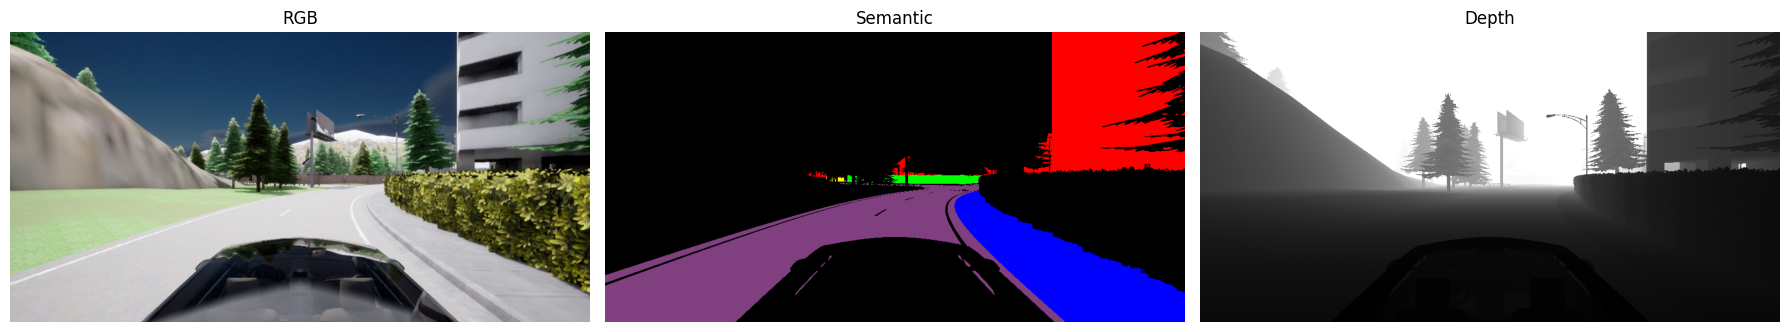

In [54]:
def visualize_sample(index):
    """
    Visualize RGB / Semantic / Depth together
    """

    idx = f"{index:04d}"

    rgb_path = os.path.join(DATA_ROOT, "rgb", idx+".jpg")
    semantic_path = os.path.join(DATA_ROOT, "semantics", idx+".png")
    depth_path = os.path.join(DATA_ROOT, "depth", idx+".png")

    # RGB
    rgb = np.array(Image.open(rgb_path))

    # Semantic
    semantic_mask = np.array(Image.open(semantic_path))
    semantic_rgb = visualize_semantic_mask(semantic_mask)

    # Depth
    depth_vis = Image.open(depth_path)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(rgb)
    axes[0].set_title("RGB")
    axes[0].axis("off")

    axes[1].imshow(semantic_rgb)
    axes[1].set_title("Semantic")
    axes[1].axis("off")

    axes[2].imshow(depth_vis, cmap="gray")
    axes[2].set_title("Depth")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


visualize_sample(0)

In [55]:
boxes = get_gz_json(os.path.join(DATA_ROOT, "boxes", "0000.json.gz"))
rgb_path = os.path.join(DATA_ROOT, "rgb", "0000.jpg")

# records/results json

In [56]:
records = get_gz_json(os.path.join(DATA_ROOT, "records.json.gz"))
results = get_gz_json(os.path.join(DATA_ROOT, "results.json.gz"))

print(records)
print(results)

{'meta_data': {'index': 'Town04_Scenario4_102_route0_11_08_03_33_41', 'town': 'Carla/Maps/Town04'}, 'states': [], 'lights': [], 'route': [], 'ego_actions': [], 'adv_actions': []}
{'timestamp': 'Town04_Scenario4_102_route0_11_08_03_33_41', 'index': 0, 'route_id': 'RouteScenario_102_rep0', 'status': 'Completed', 'num_infractions': 1, 'infractions': {'collisions_layout': [], 'collisions_pedestrian': [], 'collisions_vehicle': [], 'red_light': [], 'stop_infraction': [], 'outside_route_lanes': [], 'min_speed_infractions': ["Average speed is 75.61% of the surrounding traffic's one"], 'yield_emergency_vehicle_infractions': [], 'scenario_timeouts': [], 'route_dev': [], 'vehicle_blocked': [], 'route_timeout': []}, 'scores': {'score_route': 100, 'score_penalty': 0.92683, 'score_composed': 92.683}, 'meta': {'route_length': 75.956, 'duration_game': 14.85, 'duration_system': 65.097}}


# check evaluation results json

In [3]:
import os
import gzip
import json
from pathlib import Path

import numpy as np
import pandas as pd
from pprint import pprint

def get_gz_json(file_path):
    with gzip.open(file_path, "rt", encoding="utf-8") as f:
        data = json.load(f)
    return data


json_path = "/workspace/CAPSTONE_DESIGN_1/carla_garage/results/bench2drive_split/bench2drive_25_route0_05_12_01_01_41/records.json.gz"
results = get_gz_json(json_path)
pprint(results)

{'adv_actions': [{'brake': [[[0.0], [0.0]]],
                  'steer': [[[0.02227136306464672], [0.022253982722759247]]],
                  'throttle': [[[0.8500000238418579], [0.8500000238418579]]]},
                 {'brake': [[[0.0], [0.0], [0.0], [0.0]]],
                  'steer': [[[0.020874429494142532],
                             [0.020929643884301186],
                             [0.01889217272400856],
                             [0.019660303369164467]]],
                  'throttle': [[[0.8500000238418579],
                                [0.8500000238418579],
                                [0.8500000238418579],
                                [0.8500000238418579]]]},
                 {'brake': [[[0.0], [0.0], [0.0], [0.0]]],
                  'steer': [[[0.003549089189618826],
                             [0.002991447923704982],
                             [0.0022882723715156317],
                             [0.007113822735846043]]],
                  'throttle': [[[

# check boxes and heatmap

# Attention mass inside GT bounding boxes

This section evaluates whether the model's image attention is concentrated inside the ground-truth 2D bounding boxes. The attention map is resized into RGB image coordinates, normalized into a probability mass map whose values sum to 1, and then summed inside the GT box regions.


In [3]:
from PIL import Image, ImageDraw
import cv2

BENCH_ROOT_CANDIDATES = [
    Path("./CAPSTONE_DESIGN_1/carla_garage/results/bench2drive220"),
    Path("./carla_garage/results/bench2drive220"),
]
BENCH_ROOT = next((p for p in BENCH_ROOT_CANDIDATES if p.exists()), BENCH_ROOT_CANDIDATES[0])


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_attention_npz(path, key="attention"):
    data = np.load(path)
    if key in data:
        attention = data[key]
    elif len(data.files) == 1:
        attention = data[data.files[0]]
    else:
        raise KeyError(f"{path} has keys {data.files}; expected '{key}'")
    return np.asarray(attention, dtype=np.float32)


def normalize_attention_map(attention, method="probability", eps=1e-12):
    """
    Convert an attention map to a comparable mass map.

    method='probability': shift to non-negative values and divide by total sum.
    method='minmax_probability': min-max normalize first, then divide by total sum.
    """
    attention = np.asarray(attention, dtype=np.float32)
    attention = np.nan_to_num(attention, nan=0.0, posinf=0.0, neginf=0.0)

    if method == "minmax_probability":
        lo, hi = float(attention.min()), float(attention.max())
        attention = (attention - lo) / (hi - lo + eps)
    elif method == "probability":
        min_value = float(attention.min())
        if min_value < 0:
            attention = attention - min_value
    else:
        raise ValueError(f"Unknown normalization method: {method}")

    total = float(attention.sum())
    if total <= eps:
        return np.zeros_like(attention, dtype=np.float32)
    return attention / total


def resize_attention_to_image(attention, image_size=(1024, 384), normalization="probability"):
    """Resize low-resolution attention to image coordinates, then normalize its mass."""
    attention = np.asarray(attention, dtype=np.float32)
    resized = Image.fromarray(attention, mode="F").resize(image_size, resample=Image.Resampling.BILINEAR)
    return normalize_attention_map(np.asarray(resized, dtype=np.float32), method=normalization)


def clip_box_xyxy(box, width, height):
    x1, y1, x2, y2 = [float(v) for v in box]
    x1, x2 = sorted((x1, x2))
    y1, y2 = sorted((y1, y2))
    x1 = int(np.clip(np.floor(x1), 0, width))
    y1 = int(np.clip(np.floor(y1), 0, height))
    x2 = int(np.clip(np.ceil(x2), 0, width))
    y2 = int(np.clip(np.ceil(y2), 0, height))
    return x1, y1, x2, y2


def attention_mass_for_boxes(attention_mass, boxes, class_filter=None):
    """
    Return a frame-level attention score and per-box scores.

    frame score uses the union of all selected GT boxes, so overlapping boxes are not double-counted.
    per-box scores are still reported individually for object-level inspection.
    """
    height, width = attention_mass.shape
    selected = []
    per_box = []
    union_mask = np.zeros((height, width), dtype=bool)

    for box_idx, box_info in enumerate(boxes):
        cls = box_info.get("class", "unknown")
        if class_filter is not None and cls not in class_filter:
            continue

        x1, y1, x2, y2 = clip_box_xyxy(box_info["box"], width, height)
        area = max(0, x2 - x1) * max(0, y2 - y1)
        if area == 0:
            mass = 0.0
        else:
            mass = float(attention_mass[y1:y2, x1:x2].sum())
            union_mask[y1:y2, x1:x2] = True

        row = {
            "box_index": box_idx,
            "class": cls,
            "object_id": box_info.get("id"),
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "box_area_px": area,
            "attention_mass": mass,
        }
        per_box.append(row)
        selected.append(box_info)

    frame_mass = float(attention_mass[union_mask].sum()) if union_mask.any() else 0.0
    return frame_mass, per_box


def route_dirs(bench_root=BENCH_ROOT):
    bench_root = Path(bench_root)
    return sorted([p for p in bench_root.iterdir() if p.is_dir() and (p / "sensor_data").exists()])


def evaluate_attention_metric(
    bench_root=BENCH_ROOT,
    max_routes=None,
    max_frames_per_route=None,
    class_filter=None,
    image_size=(1024, 384),
    normalization="probability",
):
    bench_root = Path(bench_root)
    routes = route_dirs(bench_root)
    if max_routes is not None:
        routes = routes[:max_routes]

    frame_rows = []
    box_rows = []

    for route in routes:
        sensor_root = route / "sensor_data"
        attention_dir = sensor_root / "attention"
        box_dir = sensor_root / "vision_tasks_gt" / "2d_box"
        attention_files = sorted(attention_dir.glob("*.npz"))
        if max_frames_per_route is not None:
            attention_files = attention_files[:max_frames_per_route]

        for attention_path in attention_files:
            frame = attention_path.stem
            box_path = box_dir / f"{frame}.json"
            if not box_path.exists():
                continue

            raw_attention = load_attention_npz(attention_path)
            attention_mass = resize_attention_to_image(raw_attention, image_size=image_size, normalization=normalization)
            boxes = load_json(box_path).get("boxes", [])
            frame_mass, per_box = attention_mass_for_boxes(attention_mass, boxes, class_filter=class_filter)

            frame_rows.append({
                "route": route.name,
                "frame": frame,
                "n_gt_boxes": len(per_box),
                "gt_attention_mass": frame_mass,
                "gt_attention_percent": 100.0 * frame_mass,
                "mean_box_attention_mass": float(np.mean([b["attention_mass"] for b in per_box])) if per_box else 0.0,
                "max_box_attention_mass": float(np.max([b["attention_mass"] for b in per_box])) if per_box else 0.0,
                "attention_path": str(attention_path),
                "box_path": str(box_path),
            })

            for row in per_box:
                row.update({"route": route.name, "frame": frame})
                box_rows.append(row)

    frame_df = pd.DataFrame(frame_rows)
    box_df = pd.DataFrame(box_rows)
    return frame_df, box_df


def plot_attention_metric_sample(route_name=None, frame="0163", bench_root=BENCH_ROOT, normalization="probability"):
    routes = route_dirs(bench_root)
    route = Path(bench_root) / route_name if route_name else routes[0]
    sensor_root = route / "sensor_data"

    rgb_path = sensor_root / "rgb" / f"{frame}.png"
    attention_path = sensor_root / "attention" / f"{frame}.npz"
    box_path = sensor_root / "vision_tasks_gt" / "2d_box" / f"{frame}.json"

    rgb = Image.open(rgb_path).convert("RGB")
    attention = resize_attention_to_image(load_attention_npz(attention_path), image_size=rgb.size, normalization=normalization)
    boxes = load_json(box_path).get("boxes", [])
    frame_mass, per_box = attention_mass_for_boxes(attention, boxes)

    boxed = rgb.copy()
    draw = ImageDraw.Draw(boxed)
    for b in per_box:
        draw.rectangle([b["x1"], b["y1"], b["x2"], b["y2"]], outline="lime", width=3)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(rgb)
    axes[0].set_title(f"RGB: {route.name}/{frame}")
    axes[1].imshow(attention, cmap="magma")
    axes[1].set_title("Normalized attention mass")
    axes[2].imshow(boxed)
    axes[2].imshow(attention, cmap="magma", alpha=0.45)
    axes[2].set_title(f"GT box attention mass = {frame_mass:.4f}")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()

    return frame_mass, pd.DataFrame(per_box)


BENCH_ROOT: carla_garage/results/bench2drive220
Number of route folders: 111
sample frame GT attention mass: 0.01620040461421013


,box_index,class,object_id,x1,y1,x2,y2,box_area_px,attention_mass
0,0,car,51869,492,270,544,310,2080,0.015245
1,1,car,51860,505,264,528,283,437,0.003315


frames evaluated: 67964
boxes evaluated: 583261


,route,frame,n_gt_boxes,gt_attention_mass,gt_attention_percent,mean_box_attention_mass,max_box_attention_mass,attention_path,box_path
0,bench2drive220_route0_05_19_07_11_15,0005,5,0.064621,6.462096,0.016849,0.044636,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...
1,bench2drive220_route0_05_19_07_11_15,0006,5,0.065569,6.556918,0.017090,0.044762,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...
2,bench2drive220_route0_05_19_07_11_15,0007,5,0.065261,6.526124,0.017060,0.044485,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...
3,bench2drive220_route0_05_19_07_11_15,0008,5,0.065650,6.564984,0.017140,0.044735,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...
4,bench2drive220_route0_05_19_07_11_15,0009,5,0.066144,6.614435,0.017273,0.044939,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...


,gt_attention_mass,gt_attention_percent,n_gt_boxes
count,67964.000000,67964.000000,67964.000000
mean,0.198725,19.872547,8.581911
std,0.121252,12.125249,4.675263
min,0.000000,0.000000,0.000000
25%,0.100196,10.019569,4.000000
50%,0.196310,19.630981,8.000000
75%,0.293653,29.365317,13.000000
max,0.603948,60.394830,19.000000


,route,frames,mean_gt_attention_mass,median_gt_attention_mass,mean_gt_attention_percent,mean_gt_boxes
4,bench2drive220_route103_05_19_22_32_39,4688,0.395891,0.406268,39.589108,15.296715
28,bench2drive220_route25_05_19_12_09_15,1034,0.368690,0.394291,36.868972,14.221470
14,bench2drive220_route12_05_19_09_41_53,4651,0.320403,0.330983,32.040276,13.491292
7,bench2drive220_route106_05_20_00_14_26,4936,0.306263,0.318455,30.626293,12.116694
21,bench2drive220_route19_05_19_11_15_17,1011,0.291100,0.321817,29.110049,13.318497
65,bench2drive220_route59_05_19_16_43_39,1015,0.283402,0.289029,28.340157,15.440394
50,bench2drive220_route45_05_19_14_25_41,4456,0.277707,0.278117,27.770747,10.710952
70,bench2drive220_route63_05_19_17_11_03,337,0.272716,0.274184,27.271557,8.655786
108,bench2drive220_route98_05_19_22_02_01,714,0.233221,0.260725,23.322102,10.973389
24,bench2drive220_route21_05_19_11_36_39,1230,0.229861,0.268725,22.986117,8.239024


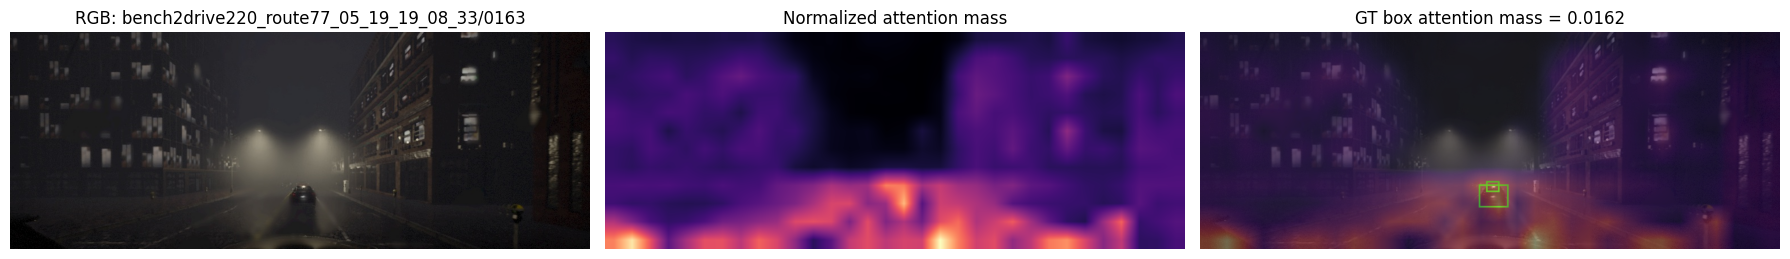

In [ ]:
print("BENCH_ROOT:", BENCH_ROOT)
print("Number of route folders:", len(route_dirs(BENCH_ROOT)))

# Quick visual sanity check on the route/frame currently open in the IDE.
sample_route = "bench2drive220_route77_05_19_19_08_33"
sample_frame_mass, sample_box_df = plot_attention_metric_sample(route_name=sample_route, frame="0163")
print("sample frame GT attention mass:", sample_frame_mass)
display(sample_box_df)

# Evaluate the full bench2drive220 result folder. Set max_routes/max_frames_per_route while iterating.
frame_attention_df, box_attention_df = evaluate_attention_metric(
    BENCH_ROOT,
    max_routes=None,
    max_frames_per_route=None,
    class_filter=None,
    normalization="probability",
)

print("frames evaluated:", len(frame_attention_df))
print("boxes evaluated:", len(box_attention_df))
display(frame_attention_df.head())

display(
    frame_attention_df[["gt_attention_mass", "gt_attention_percent", "n_gt_boxes"]]
    .describe()
)

display(
    frame_attention_df.groupby("route", as_index=False)
    .agg(
        frames=("frame", "count"),
        mean_gt_attention_mass=("gt_attention_mass", "mean"),
        median_gt_attention_mass=("gt_attention_mass", "median"),
        mean_gt_attention_percent=("gt_attention_percent", "mean"),
        mean_gt_boxes=("n_gt_boxes", "mean"),
    )
    .sort_values("mean_gt_attention_mass", ascending=False)
    .head(20)
)


### class filter

BENCH_ROOT: carla_garage/results/bench2drive220
Number of route folders: 111
sample frame GT attention mass: 0.01620040461421013


,box_index,class,object_id,x1,y1,x2,y2,box_area_px,attention_mass
0,0,car,51869,492,270,544,310,2080,0.015245
1,1,car,51860,505,264,528,283,437,0.003315


frames evaluated: 67964
boxes evaluated: 339859


,route,frame,n_gt_boxes,gt_attention_mass,gt_attention_percent,mean_box_attention_mass,max_box_attention_mass,attention_path,box_path
0,bench2drive220_route0_05_19_07_11_15,0005,2,0.014971,1.497058,0.008741,0.013557,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...
1,bench2drive220_route0_05_19_07_11_15,0006,2,0.015674,1.567363,0.009138,0.014210,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...
2,bench2drive220_route0_05_19_07_11_15,0007,2,0.015586,1.558644,0.009066,0.014158,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...
3,bench2drive220_route0_05_19_07_11_15,0008,2,0.015717,1.571677,0.009149,0.014268,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...
4,bench2drive220_route0_05_19_07_11_15,0009,2,0.015945,1.594473,0.009278,0.014485,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...


,gt_attention_mass,gt_attention_percent,n_gt_boxes
count,67964.000000,67964.000000,67964.000000
mean,0.133609,13.360858,5.000574
std,0.111257,11.125669,3.518667
min,0.000000,0.000000,0.000000
25%,0.034523,3.452311,2.000000
50%,0.099990,9.998953,4.000000
75%,0.248357,24.835662,8.000000
max,0.556288,55.628788,12.000000


,route,frames,mean_gt_attention_mass,median_gt_attention_mass,mean_gt_attention_percent,mean_gt_boxes
14,bench2drive220_route12_05_19_09_41_53,4651,0.303147,0.325743,30.314745,9.658353
7,bench2drive220_route106_05_20_00_14_26,4936,0.267762,0.276435,26.776164,8.404781
50,bench2drive220_route45_05_19_14_25_41,4456,0.257976,0.268465,25.797562,7.502244
4,bench2drive220_route103_05_19_22_32_39,4688,0.256962,0.263397,25.696165,11.273464
43,bench2drive220_route39_05_19_13_52_32,307,0.202437,0.207607,20.243725,5.042345
38,bench2drive220_route34_05_19_13_00_20,287,0.195568,0.215795,19.556832,5.411150
22,bench2drive220_route1_05_19_07_17_09,428,0.166672,0.178768,16.667197,5.072430
83,bench2drive220_route75_05_19_18_58_16,279,0.159177,0.120734,15.917737,4.630824
84,bench2drive220_route76_05_19_19_03_41,225,0.158223,0.110197,15.822345,3.782222
47,bench2drive220_route42_05_19_14_07_09,692,0.147738,0.134012,14.773829,3.500000


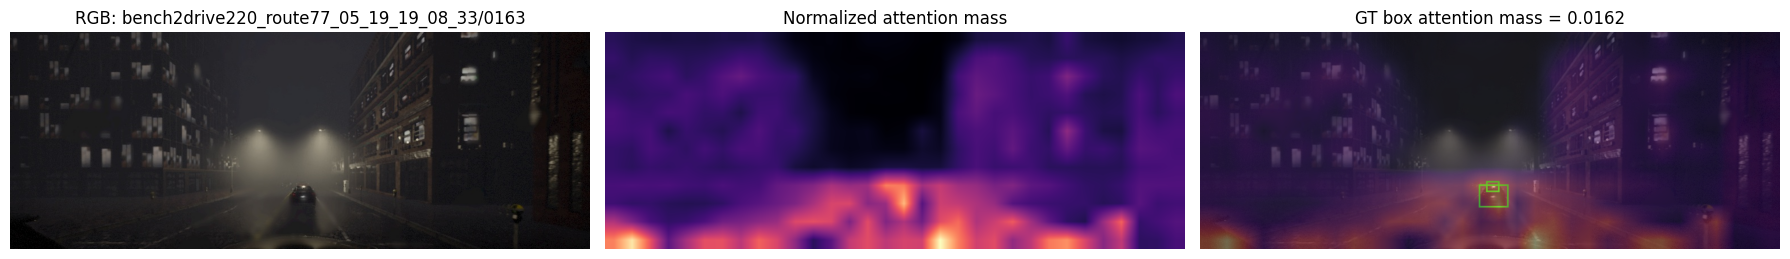

In [7]:
print("BENCH_ROOT:", BENCH_ROOT)
print("Number of route folders:", len(route_dirs(BENCH_ROOT)))

# Quick visual sanity check on the route/frame currently open in the IDE.
sample_route = "bench2drive220_route77_05_19_19_08_33"
sample_frame_mass, sample_box_df = plot_attention_metric_sample(route_name=sample_route, frame="0163")
print("sample frame GT attention mass:", sample_frame_mass)
display(sample_box_df)

# Evaluate the full bench2drive220 result folder. Set max_routes/max_frames_per_route while iterating.
frame_attention_df, box_attention_df = evaluate_attention_metric(
    BENCH_ROOT,
    max_routes=None,
    max_frames_per_route=None,
    class_filter=['car', 'walker', 'emergency_vehicle'], # only consider important objects
    normalization="probability",
)

print("frames evaluated:", len(frame_attention_df))
print("boxes evaluated:", len(box_attention_df))
display(frame_attention_df.head())

display(
    frame_attention_df[["gt_attention_mass", "gt_attention_percent", "n_gt_boxes"]]
    .describe()
)

display(
    frame_attention_df.groupby("route", as_index=False)
    .agg(
        frames=("frame", "count"),
        mean_gt_attention_mass=("gt_attention_mass", "mean"),
        median_gt_attention_mass=("gt_attention_mass", "median"),
        mean_gt_attention_percent=("gt_attention_percent", "mean"),
        mean_gt_boxes=("n_gt_boxes", "mean"),
    )
    .sort_values("mean_gt_attention_mass", ascending=False)
    .head(20)
)


# Attention metric around collision frames

This section uses `debug_results.json` to find collision routes, estimates the collision frame from the collided actor ID in the GT 2D boxes, then evaluates the same normalized-attention-in-GT-box metric only inside a sliding frame window around each collision. For vehicle/pedestrian collisions, the collision frame is approximated as the frame where the collided actor has the smallest GT distance to ego.


In [ ]:
import re

COLLISION_KEYS = ["collisions_vehicle", "collisions_pedestrian", "collisions_layout"]
COLLISION_PATTERN = re.compile(
    r"type=(?P<type>.+?) and id=(?P<object_id>\d+) at "
    r"\(x=(?P<x>-?\d+(?:\.\d+)?), y=(?P<y>-?\d+(?:\.\d+)?), z=(?P<z>-?\d+(?:\.\d+)?)\)"
)


def parse_collision_message(message):
    match = COLLISION_PATTERN.search(message)
    if not match:
        return {
            "object_type": None,
            "object_id": None,
            "collision_x": np.nan,
            "collision_y": np.nan,
            "collision_z": np.nan,
            "collision_message": message,
        }

    parsed = match.groupdict()
    return {
        "object_type": parsed["type"],
        "object_id": int(parsed["object_id"]),
        "collision_x": float(parsed["x"]),
        "collision_y": float(parsed["y"]),
        "collision_z": float(parsed["z"]),
        "collision_message": message,
    }


def load_collision_events(debug_json_path=BENCH_ROOT / "debug_results.json"):
    debug_json_path = Path(debug_json_path)
    debug_results = load_json(debug_json_path)
    records = debug_results.get("_checkpoint", {}).get("records", [])

    events = []
    for record in records:
        infractions = record.get("infractions", {})
        for collision_key in COLLISION_KEYS:
            for collision_idx, message in enumerate(infractions.get(collision_key, [])):
                event = parse_collision_message(message)
                event.update({
                    "route": record.get("timestamp"),
                    "route_index": record.get("index"),
                    "route_id": record.get("route_id"),
                    "collision_kind": collision_key,
                    "collision_index_in_kind": collision_idx,
                    "score_composed": record.get("scores", {}).get("score_composed"),
                    "duration_game": record.get("meta", {}).get("duration_game"),
                })
                events.append(event)

    return pd.DataFrame(events)


def find_actor_observations(route_dir, object_id):
    box_dir = Path(route_dir) / "sensor_data" / "vision_tasks_gt" / "2d_box"
    rows = []
    if object_id is None or not box_dir.exists():
        return pd.DataFrame(rows)

    for box_path in sorted(box_dir.glob("*.json")):
        frame = box_path.stem
        for box_idx, box_info in enumerate(load_json(box_path).get("boxes", [])):
            if box_info.get("id") != object_id:
                continue
            x1, y1, x2, y2 = clip_box_xyxy(box_info["box"], width=1024, height=384)
            rows.append({
                "frame": frame,
                "frame_int": int(frame),
                "box_index": box_idx,
                "class": box_info.get("class"),
                "object_id": object_id,
                "distance": box_info.get("distance", np.nan),
                "depth": box_info.get("depth", np.nan),
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "box_area_px": max(0, x2 - x1) * max(0, y2 - y1),
            })

    return pd.DataFrame(rows)


def estimate_collision_frame(route_dir, object_id):
    """Estimate collision frame from GT boxes; fallback to the route's final saved attention frame."""
    observations = find_actor_observations(route_dir, object_id)
    if len(observations):
        valid = observations.dropna(subset=["distance"])
        if len(valid):
            hit = valid.loc[valid["distance"].astype(float).idxmin()]
        else:
            hit = observations.iloc[-1]
        return str(hit["frame"]), "min_actor_distance", observations

    attention_files = sorted((Path(route_dir) / "sensor_data" / "attention").glob("*.npz"))
    if attention_files:
        return attention_files[-1].stem, "fallback_last_attention_frame", observations

    return None, "no_attention_frames", observations


def frame_window(center_frame, available_frames, radius=10):
    center = int(center_frame)
    available = sorted(int(frame) for frame in available_frames)
    selected = [frame for frame in available if center - radius <= frame <= center + radius]
    return [f"{frame:04d}" for frame in selected]


def evaluate_collision_attention_windows(
    bench_root=BENCH_ROOT,
    debug_json_path=None,
    window_radius=10,
    normalization="probability",
    image_size=(1024, 384),
    class_filter=None
):
    """
    Evaluate attention-in-GT-box metrics only around collision events.

    Outputs:
    - collision_events_df: one row per collision event, with estimated collision frame.
    - collision_window_frame_df: one row per route/frame in each sliding window.
    - collision_window_box_df: one row per GT box in each sliding window.
    """
    bench_root = Path(bench_root)
    debug_json_path = Path(debug_json_path) if debug_json_path else bench_root / "debug_results.json"

    collision_events_df = load_collision_events(debug_json_path)
    if len(collision_events_df) == 0:
        return collision_events_df, pd.DataFrame(), pd.DataFrame()

    frame_rows = []
    box_rows = []
    enriched_events = []

    for event_idx, event in collision_events_df.iterrows():
        route_dir = bench_root / event["route"]
        sensor_root = route_dir / "sensor_data"
        attention_dir = sensor_root / "attention"
        box_dir = sensor_root / "vision_tasks_gt" / "2d_box"

        available_frames = sorted(path.stem for path in attention_dir.glob("*.npz"))
        estimated_frame, frame_source, actor_observations = estimate_collision_frame(route_dir, event["object_id"])
        event_dict = event.to_dict()
        event_dict.update({
            "event_index": event_idx,
            "estimated_collision_frame": estimated_frame,
            "frame_source": frame_source,
            "actor_observed_frames": len(actor_observations),
        })
        enriched_events.append(event_dict)

        if estimated_frame is None:
            continue

        window_frames = frame_window(estimated_frame, available_frames, radius=window_radius)
        for frame in window_frames:
            attention_path = attention_dir / f"{frame}.npz"
            box_path = box_dir / f"{frame}.json"
            if not attention_path.exists() or not box_path.exists():
                continue

            raw_attention = load_attention_npz(attention_path)
            attention_mass = resize_attention_to_image(raw_attention, image_size=image_size, normalization=normalization)
            boxes = load_json(box_path).get("boxes", [])

            all_gt_mass, per_box = attention_mass_for_boxes(attention_mass, boxes, class_filter=class_filter)
            collision_box_rows = [row for row in per_box if row.get("object_id") == event["object_id"]]
            collision_actor_mass = float(sum(row["attention_mass"] for row in collision_box_rows))
            rel_frame = int(frame) - int(estimated_frame)

            frame_rows.append({
                "event_index": event_idx,
                "route": event["route"],
                "route_id": event["route_id"],
                "collision_kind": event["collision_kind"],
                "object_type": event["object_type"],
                "object_id": event["object_id"],
                "estimated_collision_frame": estimated_frame,
                "frame": frame,
                "relative_frame": rel_frame,
                "n_gt_boxes": len(per_box),
                "gt_attention_mass": all_gt_mass,
                "gt_attention_percent": 100.0 * all_gt_mass,
                "collision_actor_attention_mass": collision_actor_mass,
                "collision_actor_attention_percent": 100.0 * collision_actor_mass,
                "collision_actor_visible": len(collision_box_rows) > 0,
                "frame_source": frame_source,
            })

            for row in per_box:
                row.update({
                    "event_index": event_idx,
                    "route": event["route"],
                    "frame": frame,
                    "relative_frame": rel_frame,
                    "is_collision_actor": row.get("object_id") == event["object_id"],
                    "collision_object_id": event["object_id"],
                    "collision_kind": event["collision_kind"],
                })
                box_rows.append(row)

    return pd.DataFrame(enriched_events), pd.DataFrame(frame_rows), pd.DataFrame(box_rows)


def summarize_collision_attention(collision_window_frame_df):
    if len(collision_window_frame_df) == 0:
        return pd.DataFrame()

    return (
        collision_window_frame_df
        .groupby("event_index", as_index=False)
        .agg(
            route=("route", "first"),
            object_id=("object_id", "first"),
            object_type=("object_type", "first"),
            collision_kind=("collision_kind", "first"),
            estimated_collision_frame=("estimated_collision_frame", "first"),
            window_frames=("frame", "count"),
            mean_gt_attention_mass=("gt_attention_mass", "mean"),
            max_gt_attention_mass=("gt_attention_mass", "max"),
            at_collision_gt_attention_mass=(
                "gt_attention_mass",
                lambda s: s[collision_window_frame_df.loc[s.index, "relative_frame"] == 0].iloc[0]
                if (collision_window_frame_df.loc[s.index, "relative_frame"] == 0).any()
                else np.nan,
            ),
            mean_collision_actor_attention_mass=("collision_actor_attention_mass", "mean"),
            max_collision_actor_attention_mass=("collision_actor_attention_mass", "max"),
            at_collision_actor_attention_mass=(
                "collision_actor_attention_mass",
                lambda s: s[collision_window_frame_df.loc[s.index, "relative_frame"] == 0].iloc[0]
                if (collision_window_frame_df.loc[s.index, "relative_frame"] == 0).any()
                else np.nan,
            ),
            actor_visible_frames=("collision_actor_visible", "sum"),
        )
        .sort_values("at_collision_actor_attention_mass", ascending=False)
    )


In [6]:
DEBUG_RESULTS_PATH = BENCH_ROOT / "debug_results.json"
COLLISION_WINDOW_RADIUS = 10

collision_events_df, collision_window_frame_df, collision_window_box_df = evaluate_collision_attention_windows(
    bench_root=BENCH_ROOT,
    debug_json_path=DEBUG_RESULTS_PATH,
    window_radius=COLLISION_WINDOW_RADIUS,
    normalization="probability",
)

print("collision events:", len(collision_events_df))
print("collision-window frames evaluated:", len(collision_window_frame_df))
print("collision-window boxes evaluated:", len(collision_window_box_df))

display(collision_events_df.head(20))
display(collision_window_frame_df.head(20))

display(
    collision_window_frame_df[[
        "gt_attention_mass",
        "gt_attention_percent",
        "collision_actor_attention_mass",
        "collision_actor_attention_percent",
        "relative_frame",
    ]].describe()
)

collision_attention_summary_df = summarize_collision_attention(collision_window_frame_df)
display(collision_attention_summary_df.head(30))

# Mean temporal profile around collision frame. relative_frame=0 is the estimated collision frame.
display(
    collision_window_frame_df.groupby("relative_frame", as_index=False)
    .agg(
        events=("event_index", "nunique"),
        mean_gt_attention_mass=("gt_attention_mass", "mean"),
        mean_collision_actor_attention_mass=("collision_actor_attention_mass", "mean"),
        actor_visible_rate=("collision_actor_visible", "mean"),
    )
)


collision events: 27
collision-window frames evaluated: 522
collision-window boxes evaluated: 3455


,object_type,object_id,collision_x,collision_y,collision_z,collision_message,route,route_index,route_id,collision_kind,collision_index_in_kind,score_composed,duration_game,event_index,estimated_collision_frame,frame_source,actor_observed_frames
0,vehicle.audi.tt,14973,3070.693,6262.108,370.521,Agent collided against object with type=vehicl...,bench2drive220_route3_05_19_07_30_08,3,RouteScenario_1792_rep0,collisions_vehicle,0,58.749000,15.45,0,0116,min_actor_distance,304
1,vehicle.mercedes.coupe_2020,18689,1176.579,5375.946,370.873,Agent collided against object with type=vehicl...,bench2drive220_route4_05_19_07_35_35,4,RouteScenario_1825_rep0,collisions_vehicle,0,51.798495,106.95,1,0294,min_actor_distance,1842
2,vehicle.audi.tt,33481,2536.403,2073.047,356.946,Agent collided against object with type=vehicl...,bench2drive220_route8_05_19_08_28_32,8,RouteScenario_2050_rep0,collisions_vehicle,0,60.000000,13.75,2,0178,min_actor_distance,31
3,vehicle.audi.tt,40889,-1381.157,5321.996,376.652,Agent collided against object with type=vehicl...,bench2drive220_route10_05_19_08_37_18,10,RouteScenario_2084_rep0,collisions_vehicle,0,54.812400,193.70,3,0136,min_actor_distance,3654
4,vehicle.audi.tt,48308,2769.961,1600.535,343.664,Agent collided against object with type=vehicl...,bench2drive220_route12_05_19_09_41_53,12,RouteScenario_2091_rep0,collisions_vehicle,0,50.623800,232.80,4,2614,min_actor_distance,3438
5,vehicle.chevrolet.impala,52017,1985.641,2171.578,362.191,Agent collided against object with type=vehicl...,bench2drive220_route13_05_19_10_44_15,13,RouteScenario_2115_rep0,collisions_vehicle,0,60.000000,14.40,5,0287,fallback_last_attention_frame,0
6,vehicle.nissan.patrol_2021,70507,-1471.030,3917.948,363.743,Agent collided against object with type=vehicl...,bench2drive220_route18_05_19_11_09_27,18,RouteScenario_2164_rep0,collisions_vehicle,0,35.886600,17.70,6,0253,min_actor_distance,157
7,vehicle.nissan.patrol_2021,70507,-1471.030,3917.948,363.743,Agent collided against object with type=vehicl...,bench2drive220_route18_05_19_11_09_27,18,RouteScenario_2164_rep0,collisions_vehicle,1,35.886600,17.70,7,0253,min_actor_distance,157
8,vehicle.mini.cooper_s_2021,74322,920.595,3684.278,370.789,Agent collided against object with type=vehicl...,bench2drive220_route19_05_19_11_15_17,19,RouteScenario_2201_rep0,collisions_vehicle,0,51.439200,50.80,8,1015,fallback_last_attention_frame,0
9,vehicle.dodge.charger_2020,89119,-2222.489,6376.773,378.050,Agent collided against object with type=vehicl...,bench2drive220_route23_05_19_11_59_51,23,RouteScenario_2283_rep0,collisions_vehicle,0,60.000000,15.85,9,0065,min_actor_distance,30


,event_index,route,route_id,collision_kind,object_type,object_id,estimated_collision_frame,frame,relative_frame,n_gt_boxes,gt_attention_mass,gt_attention_percent,collision_actor_attention_mass,collision_actor_attention_percent,collision_actor_visible,frame_source
0,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0106,-10,3,0.280655,28.065503,0.067088,6.708770,True,min_actor_distance
1,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0107,-9,3,0.335538,33.553752,0.073496,7.349637,True,min_actor_distance
2,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0108,-8,3,0.348640,34.864032,0.074333,7.433289,True,min_actor_distance
3,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0109,-7,3,0.345716,34.571570,0.075792,7.579228,True,min_actor_distance
4,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0110,-6,3,0.344707,34.470659,0.076470,7.647046,True,min_actor_distance
5,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0111,-5,3,0.347002,34.700209,0.077393,7.739251,True,min_actor_distance
6,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0112,-4,3,0.351623,35.162270,0.077855,7.785479,True,min_actor_distance
7,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0113,-3,3,0.363860,36.385971,0.079015,7.901479,True,min_actor_distance
8,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0114,-2,3,0.362161,36.216110,0.080634,8.063361,True,min_actor_distance
9,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0115,-1,3,0.354501,35.450125,0.077752,7.775246,True,min_actor_distance


,gt_attention_mass,gt_attention_percent,collision_actor_attention_mass,collision_actor_attention_percent,relative_frame
count,522.000000,522.000000,522.000000,522.000000,522.000000
mean,0.197209,19.720923,0.101255,10.125543,-0.498084
std,0.100898,10.089832,0.088099,8.809911,6.005515
min,0.000000,0.000000,0.000000,0.000000,-10.000000
25%,0.128848,12.884835,0.000000,0.000000,-6.000000
50%,0.218989,21.898937,0.114313,11.431284,-1.000000
75%,0.265327,26.532670,0.181386,18.138625,5.000000
max,0.429793,42.979255,0.272829,27.282867,10.000000


,event_index,route,object_id,object_type,collision_kind,estimated_collision_frame,window_frames,mean_gt_attention_mass,max_gt_attention_mass,at_collision_gt_attention_mass,mean_collision_actor_attention_mass,max_collision_actor_attention_mass,at_collision_actor_attention_mass,actor_visible_frames
23,23,bench2drive220_route95_05_19_21_41_43,28535,vehicle.lincoln.mkz_2020,collisions_vehicle,0083,21,0.254505,0.275204,0.250278,0.252369,0.272829,0.248047,21
25,25,bench2drive220_route106_05_20_00_14_26,76641,vehicle.nissan.patrol_2021,collisions_vehicle,4719,21,0.275300,0.279353,0.278215,0.228619,0.231519,0.230825,21
20,20,bench2drive220_route74_05_19_18_53_15,37731,vehicle.dodge.charger_police_2020,collisions_vehicle,0153,21,0.129081,0.247176,0.231179,0.122563,0.245253,0.224018,11
6,6,bench2drive220_route18_05_19_11_09_27,70507,vehicle.nissan.patrol_2021,collisions_vehicle,0253,21,0.187348,0.300448,0.300448,0.078261,0.214990,0.214990,11
7,7,bench2drive220_route18_05_19_11_09_27,70507,vehicle.nissan.patrol_2021,collisions_vehicle,0253,21,0.187348,0.300448,0.300448,0.078261,0.214990,0.214990,11
21,21,bench2drive220_route85_05_19_20_13_32,89533,vehicle.ford.mustang,collisions_vehicle,0149,21,0.311316,0.346256,0.326273,0.114716,0.228956,0.211959,11
16,16,bench2drive220_route46_05_19_15_31_14,29665,vehicle.ford.mustang,collisions_vehicle,0145,16,0.129296,0.255762,0.236124,0.092378,0.226398,0.200224,11
14,14,bench2drive220_route42_05_19_14_07_09,14826,vehicle.audi.tt,collisions_vehicle,0139,21,0.251266,0.334810,0.229136,0.194810,0.201715,0.189304,21
22,22,bench2drive220_route94_05_19_21_33_43,23791,vehicle.dodge.charger_2020,collisions_vehicle,0062,21,0.174040,0.232060,0.217958,0.108198,0.221597,0.184340,11
9,9,bench2drive220_route23_05_19_11_59_51,89119,vehicle.dodge.charger_2020,collisions_vehicle,0065,21,0.126371,0.240660,0.194891,0.113161,0.230034,0.181408,11


,relative_frame,events,mean_gt_attention_mass,mean_collision_actor_attention_mass,actor_visible_rate
0,-10,27,0.204364,0.117817,0.851852
1,-9,27,0.209079,0.120891,0.851852
2,-8,27,0.212172,0.124206,0.851852
3,-7,27,0.214131,0.127320,0.851852
4,-6,27,0.215949,0.129293,0.851852
5,-5,27,0.215854,0.129823,0.851852
6,-4,27,0.217450,0.131354,0.851852
7,-3,27,0.218920,0.133370,0.851852
8,-2,27,0.217691,0.131169,0.851852
9,-1,27,0.215899,0.130368,0.851852
